# 🏥 Notebook: WebMD_AI_Pipeline.ipynb
_**Part of the WebMD Drug Reviews AI Project Series**_

*An end-to-end AI pipeline for analyzing patient drug reviews using ML, DL, NLP, RAG, and LLM.*

---

## 🧭 Table of Contents

1. [📘 Overview & Navigation](#overview)
2. [🧠 Context & Purpose](#context)
3. [🗂️ Project Structure](#structure)
4. [📦 Dependencies & Setup](#dependencies)
5. [🛠️ Config & Constants](#config)
6. [📥 Data Loading & Kaggle Setup](#data)
7. [📊 Phase 1 — Exploratory Data Analysis](#eda)
8. [🤖 Phase 2 — Machine Learning](#ml)
9. [🧠 Phase 3 — Deep Learning & NLP](#dl)
10. [🔍 Phase 4 — RAG System](#rag)
11. [💬 Phase 5 — LLM Integration](#llm)
12. [🖥️ Gradio Dashboard](#gradio)
13. [📚 Resources & Contributors](#resources)

> **Quick Links:** [🏠 Home](#overview) | [📊 EDA](#eda) | [🤖 ML](#ml) | [🧠 DL/NLP](#dl) | [🔍 RAG](#rag) | [💬 LLM](#llm) | [🖥️ Demo](#gradio)

---

## 📘 Overview & Navigation <a name='overview'></a>

This is a single, self-contained notebook that implements a **complete AI pipeline** for analyzing patient drug reviews from WebMD.

It walks through five progressive phases — from raw data exploration to LLM-powered answer generation — finishing with an interactive **Gradio dashboard** that lets users explore every model in real-time.

---

## 🧠 Context & Purpose <a name='context'></a>

**🔍 Purpose:**  
To build an intelligent drug review analysis system capable of predicting effectiveness, classifying sentiment, extracting side effects, and answering medical questions using semantic retrieval and LLM generation.

**🎯 Objectives:**
- Clean and analyze ~360K+ patient drug reviews from WebMD
- Predict drug effectiveness ratings (1–5) using traditional ML
- Classify review sentiment (positive/negative) with a BiLSTM + TF-IDF ensemble
- Extract side effects from free-text reviews using negation-aware keyword matching
- Enable semantic search over reviews using ChromaDB + SentenceTransformers
- Generate natural language answers using an OpenRouter LLM (optional)
- Expose all capabilities through an interactive Gradio interface

**📘 Context:**  
Patients often leave detailed but unstructured reviews online. This pipeline extracts structured insights from that data, enabling healthcare researchers and developers to understand drug experiences at scale.

**🗓 Metadata:**
- **Dataset:** WebMD Drug Reviews (~362K rows)
- **Version:** 1.0.0
- **Status:** Complete Pipeline
- **Environment:** Google Colab (GPU recommended)

## 🗂️ Project Structure <a name='structure'></a>

### Pipeline Phases:

| 🔢 Phase | 🏷️ Name | 🛠️ Techniques | 📤 Output |
|----------|---------|--------------|----------|
| 1 | Exploratory Data Analysis | Pandas, Matplotlib, Seaborn | 8 visualizations + `webmd_cleaned.csv` |
| 2 | Machine Learning | Random Forest, XGBoost | `rf_effectiveness_model.pkl` |
| 3 | Deep Learning & NLP | BiLSTM, TF-IDF + SVC Ensemble | `lstm_sentiment_model.keras` |
| 4 | RAG System | ChromaDB, SentenceTransformers | `chroma_db/` vector index |
| 5 | LLM Integration | OpenRouter API (optional) | Natural language summaries |

### Key Features:
- **Intelligent preprocessing** — date parsing, rating validation, duplicate removal, text length computation
- **Stratified splits** — consistent 70/15/15 train/val/test across all phases
- **Negation-aware side effect extraction** — distinguishes "had no headache" from "had a headache"
- **Weighted ensemble** — TF-IDF (80%) + BiLSTM (20%) for optimal sentiment accuracy
- **Semantic retrieval** — cosine-similarity search over 50K embedded reviews
- **LLM fallback** — gracefully degrades to structured template if no API key is set
- **Full Gradio UI** — all phases accessible from a single tabbed web interface

## 📦 Dependencies & Setup <a name='dependencies'></a>

### Required Packages:

```
numpy              # Numerical computing
pandas             # Data manipulation
matplotlib         # Plotting
seaborn            # Statistical visualization
scikit-learn       # Machine learning models
xgboost            # Gradient boosting
joblib             # Model persistence
tensorflow         # Deep learning (BiLSTM)
nltk               # NLP utilities
chromadb           # Vector database
sentence-transformers  # Text embeddings
openai             # OpenRouter LLM client
gradio             # Interactive UI
python-dotenv      # Environment variable management
kagglehub          # Dataset download
```

### ⚙️ Hardware Recommendation:
> 🚀 **GPU Runtime strongly recommended** for Phase 3 (BiLSTM training).  
> In Colab: `Runtime → Change runtime type → T4 GPU`

### 🔑 Optional — LLM Key:
> To enable Phase 5 LLM generation, set `OPENROUTER_API_KEY` as a Colab secret or environment variable.  
> Get a free key at [openrouter.ai](https://openrouter.ai). The pipeline works fully without it.

In [18]:
# @title 📦 Install Dependencies
# @markdown Run this cell once to install all required packages.

!pip install -q \
    numpy pandas matplotlib seaborn \
    scikit-learn xgboost joblib \
    tensorflow \
    nltk \
    chromadb sentence-transformers \
    openai python-dotenv \
    gradio \
    kagglehub

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ All dependencies installed.")

✅ All dependencies installed.


In [19]:
# @title 📥 Core Imports

import os
import re
import warnings
import threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.sparse import hstack

# Suppress noisy logs
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TF_CPP_MIN_LOG_LEVEL']   = '3'

# Load .env if present
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Imports complete.")

✅ Imports complete.


## 🛠️ Config & Constants <a name='config'></a>

All tuneable parameters are defined here. Adjust these before running the pipeline:

```python
SAMPLE_SIZE   = 50_000   # Reviews to index in ChromaDB (speed vs. coverage)
NLP_SAMPLE    = 80_000   # Reviews for NLP sentiment training
EMBED_MODEL   = 'all-MiniLM-L6-v2'   # SentenceTransformer model
LLM_MODEL     = 'google/gemma-4-26b-a4b-it:free'   # OpenRouter model
BATCH_SIZE    = 1024     # BiLSTM batch (GPU) — reduced to 256 on CPU automatically
```

In [20]:
# @title ⚙️ Global Configuration

# ── Paths ─────────────────────────────────────────────────────
RAW_DATA_PATH     = 'webmd.csv'
CLEANED_DATA_PATH = 'webmd_cleaned.csv'
ML_MODEL_PATH     = 'rf_effectiveness_model.pkl'
LSTM_MODEL_PATH   = 'lstm_sentiment_model.keras'
CHROMA_DIR        = 'chroma_db'
COLLECTION_NAME   = 'webmd_reviews'
PLOTS_DIR         = 'plots'

# ── Model Parameters ──────────────────────────────────────────
SAMPLE_SIZE    = 50_000
NLP_SAMPLE     = 80_000
VOCAB_SIZE     = 30_000
MAX_LEN        = 150
EMBED_DIM      = 128
EPOCHS         = 10
EMBED_MODEL    = 'all-MiniLM-L6-v2'
LLM_MODEL      = os.environ.get('OPENROUTER_MODEL', 'google/gemma-4-26b-a4b-it:free')

# ── Auto-detect GPU ───────────────────────────────────────────
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
GPUS = tf.config.list_physical_devices('GPU')
BATCH_SIZE = 1024 if GPUS else 256
if GPUS:
    for g in GPUS:
        tf.config.experimental.set_memory_growth(g, True)
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ── Feature / Target Definitions ─────────────────────────────
ML_FEATURES = ['Age_Num', 'Sex_Enc', 'Condition_Enc',
               'EaseofUse', 'Satisfaction', 'UsefulCount',
               'Year', 'Review_Length']
AGE_MAP = {
    '0-2': 1, '3-6': 4, '7-12': 9, '13-18': 15, '19-24': 21,
    '25-34': 29, '35-44': 39, '45-54': 49, '55-64': 59,
    '65-74': 69, '75 or over': 80
}
SIDE_EFFECT_KEYWORDS = [
    'drowsiness','dizziness','nausea','headache','fatigue','vomiting',
    'diarrhea','constipation','rash','insomnia','anxiety','depression',
    'weight gain','weight loss','dry mouth','blurred vision','sweating',
    'tremor','palpitations','shortness of breath','chest pain','itching',
    'swelling','fever','chills','muscle pain','joint pain','hair loss',
    'stomach pain','upset stomach','bloating','gas','heartburn','cramps',
    'confusion','memory loss','mood swings','irritability','numbness',
    'tingling','weakness','loss of appetite','increased appetite',
    'dry skin','acne','bruising','bleeding','infection','back pain',
]

os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"✅ Config ready | GPU: {'Yes (' + str(len(GPUS)) + ')' if GPUS else 'No (CPU mode)'}")
print(f"   Batch size: {BATCH_SIZE} | LLM model: {LLM_MODEL}")

✅ Config ready | GPU: Yes (1)
   Batch size: 1024 | LLM model: google/gemma-4-26b-a4b-it:free


## 📥 Data Loading & Kaggle Setup <a name='data'></a>

### Dataset Information:

| Field | Value |
|-------|-------|
| **Source** | Kaggle — WebMD Drug Reviews Dataset |
| **Provider** | Rohan Harode |
| **Rows** | ~362,806 reviews |
| **Columns** | Drug, Condition, Reviews, Rating, Date, EaseofUse, Effectiveness, Satisfaction, Sides, Age, Sex, UsefulCount |
| **Target (ML)** | `Effectiveness` (1–5) |
| **Target (NLP)** | `Sentiment` derived from `Satisfaction` |

### 📥 Inputs & 📤 Outputs:

**Inputs:**
- `webmd.csv` — raw Kaggle download

**Outputs:**
- `webmd_cleaned.csv` — deduplicated, null-filled, feature-engineered
- `plots/` — 8 EDA visualizations
- `rf_effectiveness_model.pkl` — trained Random Forest
- `lstm_sentiment_model.keras` — trained BiLSTM
- `chroma_db/` — persistent vector index

In [21]:
# @title 🔑 Kaggle API Setup
# @markdown Paste your Kaggle credentials below, or upload `kaggle.json` manually.

import json

KAGGLE_USERNAME = 'rohanharode07'  # @param {type:"string"}
KAGGLE_KEY      = 'KGAT_2ebc6e4a2bb4ca7f224c967b50510997'  # @param {type:"string"}

if KAGGLE_USERNAME and KAGGLE_KEY:
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    kaggle_creds = {'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}
    with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
        json.dump(kaggle_creds, f)
    os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
    print('✅ Kaggle credentials saved.')
else:
    print('⚠️  No credentials entered. If kaggle.json is already uploaded, you can skip this.')

✅ Kaggle credentials saved.


In [22]:
# @title 📥 Download Dataset

if not os.path.exists(RAW_DATA_PATH):
    import kagglehub
    path = kagglehub.dataset_download('rohanharode07/webmd-drug-reviews-dataset')
    import shutil
    for f in os.listdir(path):
        if f.endswith('.csv'):
            shutil.copy(os.path.join(path, f), RAW_DATA_PATH)
            print(f'✅ Dataset saved to: {RAW_DATA_PATH}')
            break
else:
    print(f'✅ Dataset already exists at: {RAW_DATA_PATH}')

df_raw = pd.read_csv(RAW_DATA_PATH)
print(f'   Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

✅ Dataset already exists at: webmd.csv
   Shape: 362,806 rows × 12 columns


,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I ...,5,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurtin...,5,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
2,65-74,Other,7/16/2012,warfarin (bulk) 100 % powder,144731,2,3,why did my PTINR go from a normal of 2.5 to ov...,3,Female,,0


---
## 📊 Phase 1 — Exploratory Data Analysis <a name='eda'></a>

### 🎯 Goal
Understand the data's structure, quality, and key distributions before modeling.

### 🔄 Steps
1. **Data Cleaning** — handle nulls, parse dates, remove duplicates, validate rating ranges
2. **Feature Engineering** — extract `Year`, compute `Review_Length`
3. **Visualization** — generate 8 charts covering ratings, demographics, drug/condition distributions, and review trends
4. **Save** — export `webmd_cleaned.csv` for all downstream phases

### 📤 Output
- `webmd_cleaned.csv`
- `plots/plot1_*.png` … `plots/plot8_*.png`

In [23]:
# @title 🧹 Data Cleaning & Feature Engineering

df = df_raw.copy()

# ── Fill missing values ────────────────────────────────────────
for col in ['Age', 'Condition', 'Sex', 'Sides', 'Reviews']:
    df[col] = df[col].fillna('Unknown')
for col in ['EaseofUse', 'Effectiveness', 'Satisfaction']:
    df[col] = df[col].fillna(df[col].median())

# ── Date & length features ─────────────────────────────────────
df['Date']          = pd.to_datetime(df['Date'], errors='coerce')
df['Year']          = df['Date'].dt.year
df['Reviews']       = df['Reviews'].astype(str).str.strip()
df['Review_Length'] = df['Reviews'].apply(len)

# ── Dedup & valid range ────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
for col in ['EaseofUse', 'Effectiveness', 'Satisfaction']:
    df = df[df[col].between(1, 5)]

print(f'✅ Cleaning complete')
print(f'   Duplicates removed : {before - len(df):,}')
print(f'   Final shape        : {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print(df[['EaseofUse','Effectiveness','Satisfaction','UsefulCount','Review_Length']].describe().round(2))

✅ Cleaning complete
   Duplicates removed : 947
   Final shape        : 361,859 rows × 14 columns

       EaseofUse  Effectiveness  Satisfaction  UsefulCount  Review_Length
count  361859.00      361859.00     361859.00    361859.00      361859.00
mean        4.02           3.53          3.13         6.75         297.56
std         1.32           1.46          1.61         9.33         318.04
min         1.00           1.00          1.00         0.00           0.00
25%         3.00           3.00          1.00         1.00          74.00
50%         5.00           4.00          3.00         4.00         208.00
75%         5.00           5.00          5.00         9.00         408.00
max         5.00           5.00          5.00       255.00        3145.00


In [24]:
# @title 💾 Save Cleaned Dataset

df.to_csv(CLEANED_DATA_PATH, index=False)
print(f'✅ Saved: {CLEANED_DATA_PATH}  ({len(df):,} rows)')

✅ Saved: webmd_cleaned.csv  (361,859 rows)


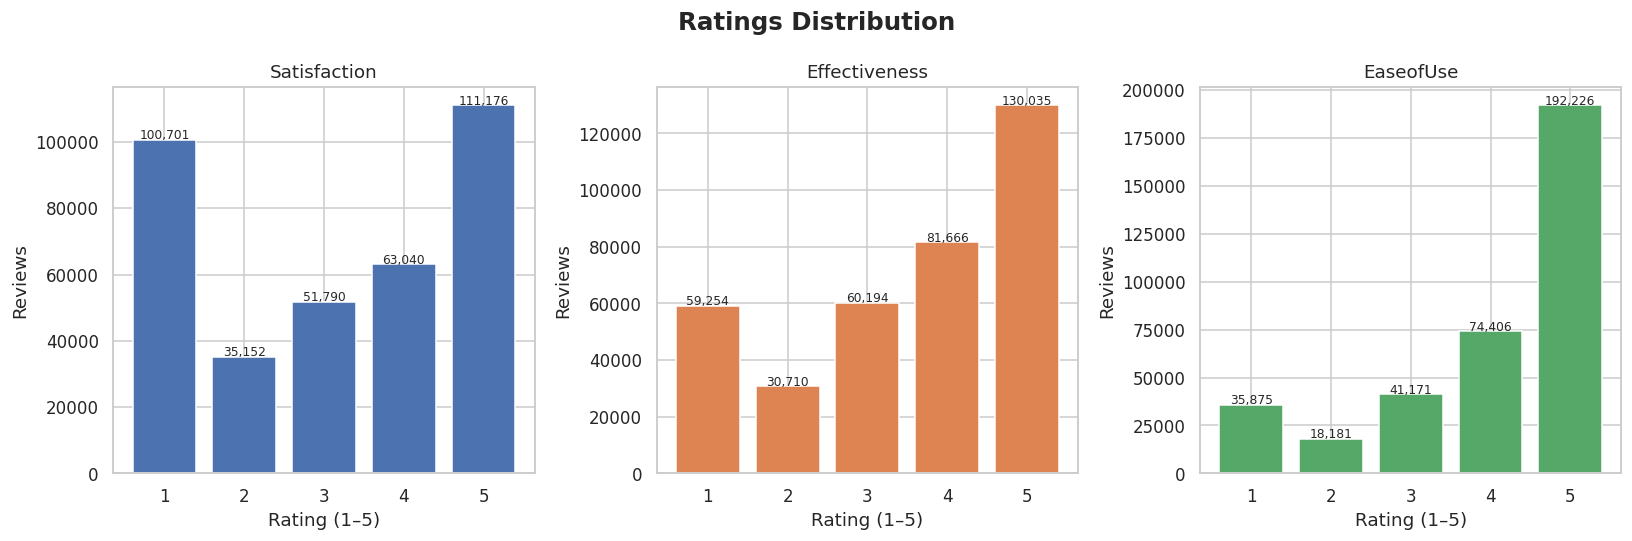

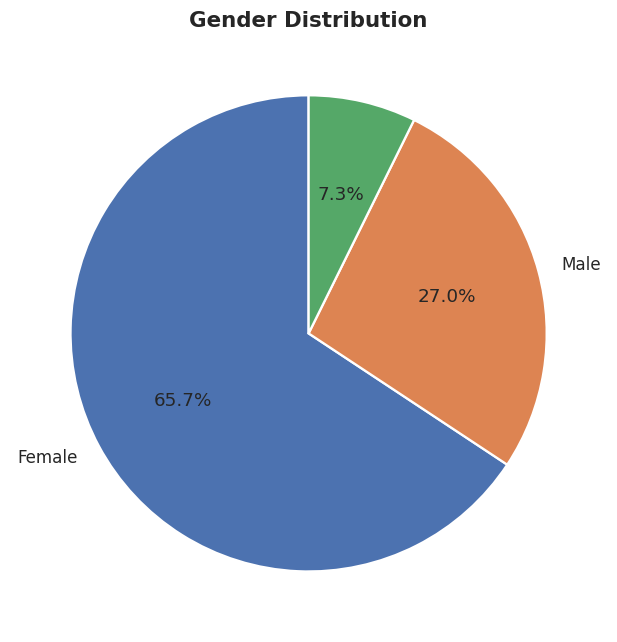

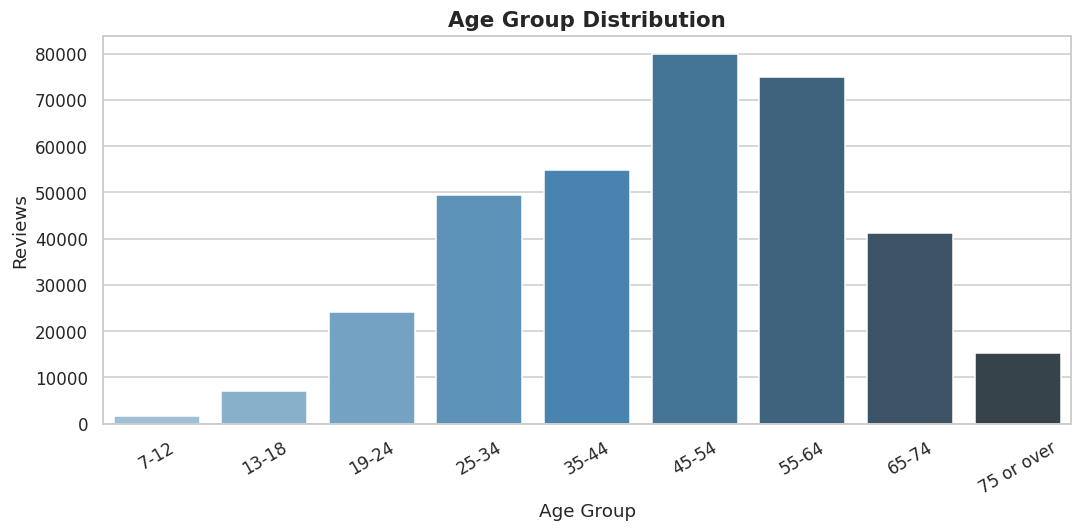

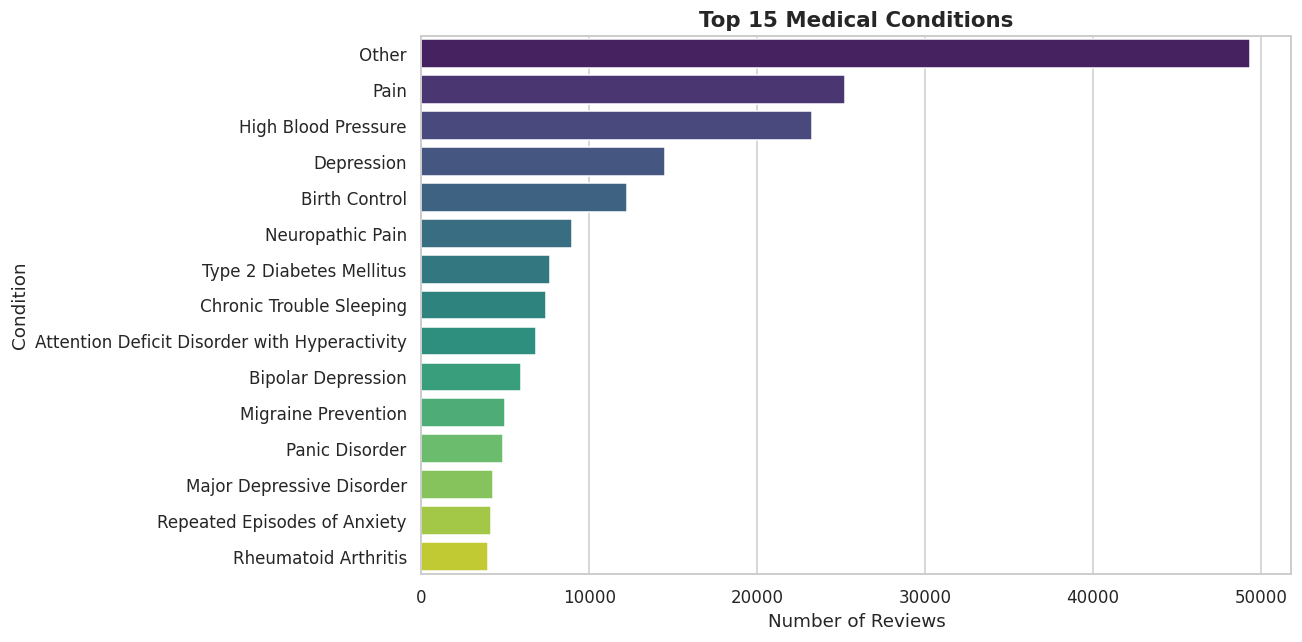

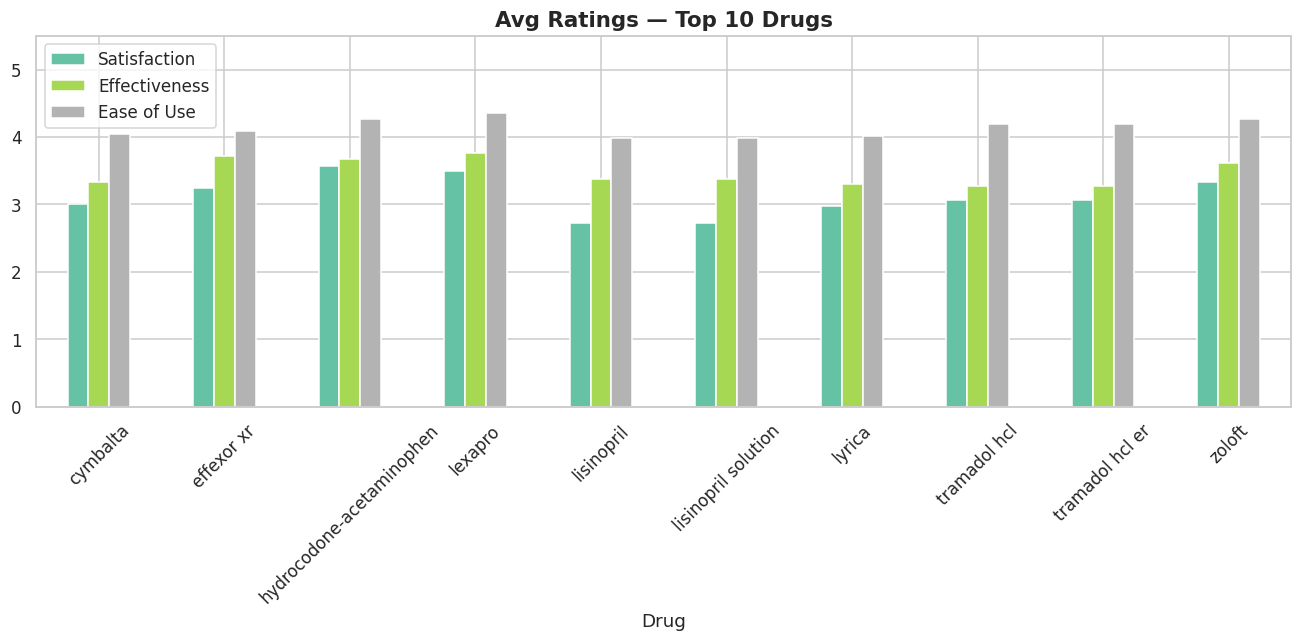

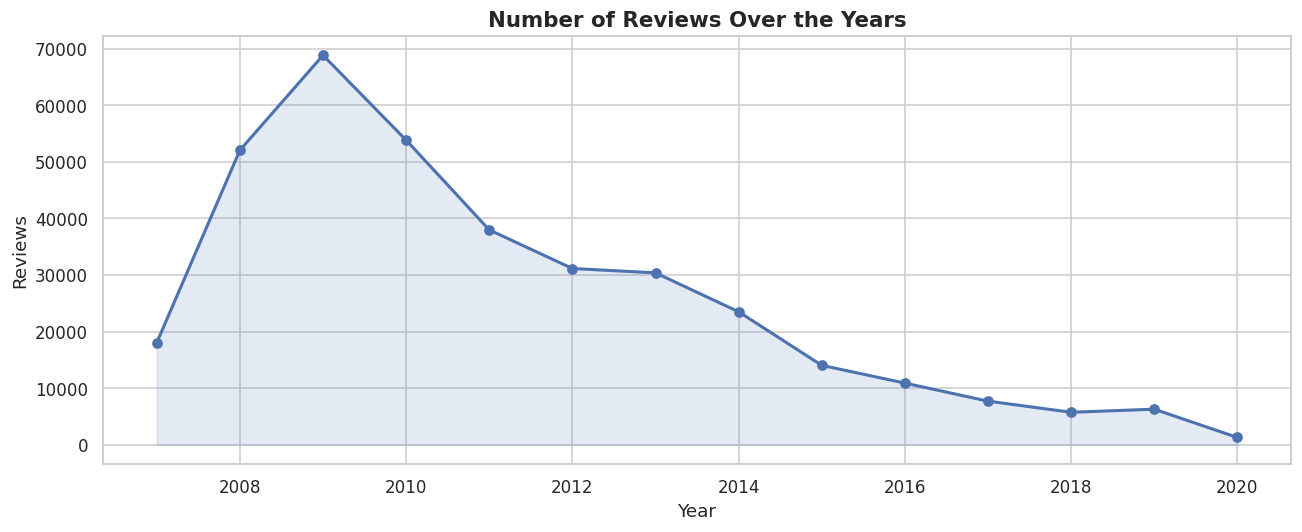

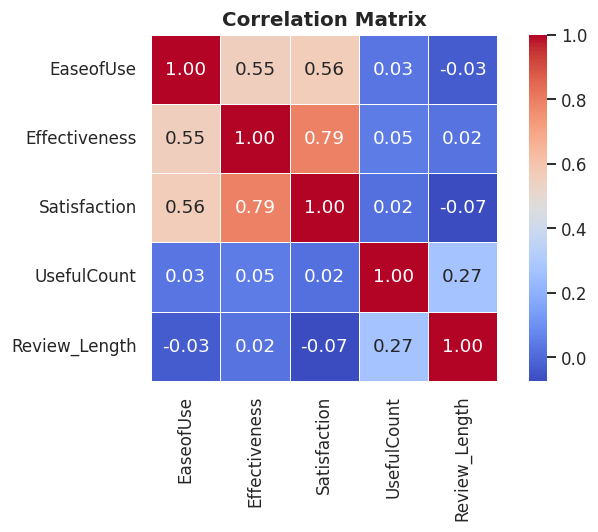

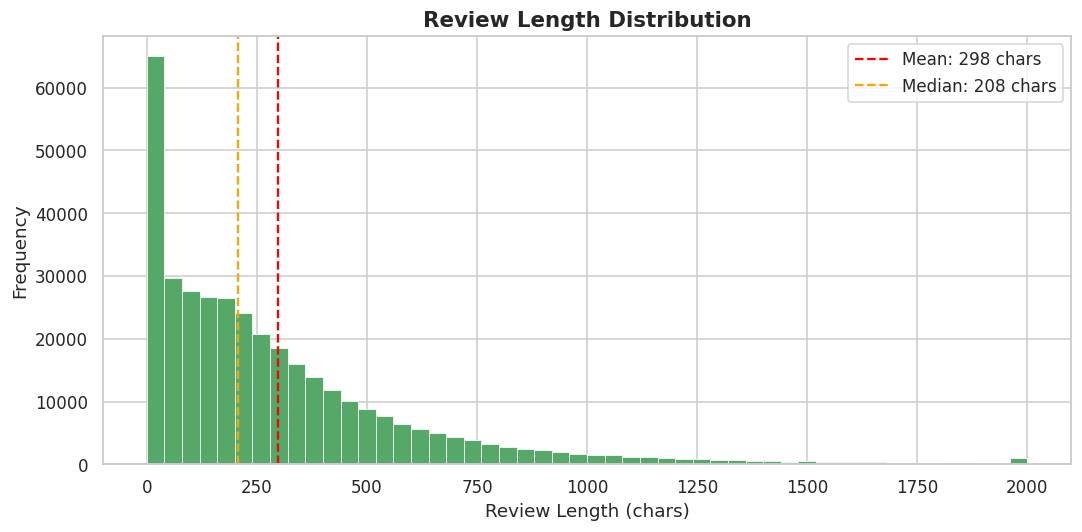


✅ All 8 EDA plots saved to: plots/


In [25]:
# @title 📊 Generate EDA Visualizations (8 Charts)

def generate_plots(df):
    plots = {}

    # ── 1. Ratings Distribution ───────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Ratings Distribution', fontsize=16, fontweight='bold')
    for ax, col, color in zip(axes,
                               ['Satisfaction','Effectiveness','EaseofUse'],
                               ['#4C72B0','#DD8452','#55A868']):
        counts = df[col].value_counts().sort_index()
        ax.bar(counts.index, counts.values, color=color, edgecolor='white')
        ax.set_title(col); ax.set_xlabel('Rating (1–5)'); ax.set_ylabel('Reviews')
        ax.set_xticks([1,2,3,4,5])
        for i, v in zip(counts.index, counts.values):
            ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=8)
    plt.tight_layout()
    p = f'{PLOTS_DIR}/plot1_ratings_distribution.png'
    plt.savefig(p); plt.show(); plots['Ratings Distribution'] = p

    # ── 2. Gender Distribution ────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 6))
    sex = df['Sex'].value_counts()
    sex = sex[sex.index != 'Unknown']
    ax.pie(sex.values, labels=sex.index, autopct='%1.1f%%',
           colors=['#4C72B0','#DD8452','#55A868'], startangle=90,
           wedgeprops={'edgecolor':'white','linewidth':1.5})
    ax.set_title('Gender Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    p = f'{PLOTS_DIR}/plot2_gender_distribution.png'
    plt.savefig(p); plt.show(); plots['Gender Distribution'] = p

    # ── 3. Age Distribution ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    age_order = ['7-12','13-18','19-24','25-34','35-44','45-54','55-64','65-74','75 or over']
    age_counts = df['Age'].value_counts().reindex([a for a in age_order if a in df['Age'].value_counts().index])
    sns.barplot(x=age_counts.index, y=age_counts.values, palette='Blues_d', ax=ax)
    ax.set_title('Age Group Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Age Group'); ax.set_ylabel('Reviews'); ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    p = f'{PLOTS_DIR}/plot3_age_distribution.png'
    plt.savefig(p); plt.show(); plots['Age Distribution'] = p

    # ── 4. Top 15 Conditions ──────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 6))
    top_cond = df['Condition'].value_counts().head(15)
    top_cond = top_cond[top_cond.index != 'Unknown']
    sns.barplot(x=top_cond.values, y=top_cond.index, palette='viridis', ax=ax)
    ax.set_title('Top 15 Medical Conditions', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Reviews'); ax.set_ylabel('Condition')
    plt.tight_layout()
    p = f'{PLOTS_DIR}/plot4_top_conditions.png'
    plt.savefig(p); plt.show(); plots['Top Conditions'] = p

    # ── 5. Top Drugs Avg Ratings ──────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 6))
    top_drugs = df['Drug'].value_counts().head(10).index
    drug_rtg = df[df['Drug'].isin(top_drugs)].groupby('Drug')[['Satisfaction','Effectiveness','EaseofUse']].mean().round(2)
    drug_rtg.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title('Avg Ratings — Top 10 Drugs', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 5.5); ax.tick_params(axis='x', rotation=45)
    ax.legend(['Satisfaction','Effectiveness','Ease of Use'])
    plt.tight_layout()
    p = f'{PLOTS_DIR}/plot5_top_drugs_ratings.png'
    plt.savefig(p); plt.show(); plots['Top Drugs Ratings'] = p

    # ── 6. Reviews Over Years ─────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    yearly = df.groupby('Year').size().reset_index(name='Count').dropna()
    ax.plot(yearly['Year'], yearly['Count'], marker='o', linewidth=2, color='#4C72B0', markersize=6)
    ax.fill_between(yearly['Year'], yearly['Count'], alpha=0.15, color='#4C72B0')
    ax.set_title('Number of Reviews Over the Years', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Reviews')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    p = f'{PLOTS_DIR}/plot6_reviews_over_years.png'
    plt.savefig(p); plt.show(); plots['Reviews Over Years'] = p

    # ── 7. Correlation Heatmap ────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    corr_cols = ['EaseofUse','Effectiveness','Satisfaction','UsefulCount','Review_Length']
    sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.5, ax=ax, square=True)
    ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    p = f'{PLOTS_DIR}/plot7_correlation_heatmap.png'
    plt.savefig(p); plt.show(); plots['Correlation Heatmap'] = p

    # ── 8. Review Length Distribution ────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    lengths = df['Review_Length'].clip(upper=2000)
    ax.hist(lengths, bins=50, color='#55A868', edgecolor='white', linewidth=0.5)
    ax.axvline(lengths.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {lengths.mean():.0f} chars')
    ax.axvline(lengths.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {lengths.median():.0f} chars')
    ax.set_title('Review Length Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Review Length (chars)'); ax.set_ylabel('Frequency')
    ax.legend(); plt.tight_layout()
    p = f'{PLOTS_DIR}/plot8_review_length_dist.png'
    plt.savefig(p); plt.show(); plots['Review Length'] = p

    print(f'\n✅ All {len(plots)} EDA plots saved to: {PLOTS_DIR}/')
    return plots

eda_plots = generate_plots(df)

---
## 🤖 Phase 2 — Machine Learning <a name='ml'></a>

### 🎯 Goal
Predict drug **Effectiveness** (1–5 stars) from structured patient features.

### 🔄 Steps
1. **Feature Engineering** — encode age groups (numeric midpoints), binary-encode sex, label-encode top-50 conditions
2. **Stratified Split** — 70% train / 15% validation / 15% test
3. **Train Models** — Random Forest and XGBoost (0-indexed labels)
4. **Evaluate** — accuracy + weighted F1, classification report
5. **Save Best** — `rf_effectiveness_model.pkl`

### 📥 Inputs & 📤 Outputs:
- **Input:** `webmd_cleaned.csv`
- **Output:** `rf_effectiveness_model.pkl`

### 📋 Features Used:

| Feature | Description |
|---------|-------------|
| `Age_Num` | Age group mapped to numeric midpoint |
| `Sex_Enc` | Binary: 1 = Female, 0 = Male |
| `Condition_Enc` | Label-encoded top-50 conditions |
| `EaseofUse` | Rating 1–5 |
| `Satisfaction` | Rating 1–5 |
| `UsefulCount` | Number of helpful votes |
| `Year` | Year of review |
| `Review_Length` | Character count of review text |

In [26]:
# @title 🔧 Feature Engineering for ML

from sklearn.preprocessing import LabelEncoder

df_ml = pd.read_csv(CLEANED_DATA_PATH)

df_ml['Age_Num'] = df_ml['Age'].map(AGE_MAP)
df_ml = df_ml[df_ml['Age_Num'].notna()].copy()
df_ml = df_ml[df_ml['Sex'].str.strip().isin(['Male','Female'])].copy()
df_ml['Sex_Enc'] = (df_ml['Sex'].str.strip() == 'Female').astype(int)

top_cond = df_ml['Condition'].value_counts().head(50).index
df_ml['Condition_Clean'] = df_ml['Condition'].where(df_ml['Condition'].isin(top_cond), 'Other')
le_condition = LabelEncoder()
df_ml['Condition_Enc'] = le_condition.fit_transform(df_ml['Condition_Clean'])
df_ml = df_ml[df_ml['Effectiveness'].between(1, 5)]

X_ml = df_ml[ML_FEATURES]
y_ml = df_ml['Effectiveness']

print(f'✅ ML dataset ready: {X_ml.shape[0]:,} samples, {X_ml.shape[1]} features')
print(f'   Target distribution:\n{y_ml.value_counts().sort_index().to_string()}')

✅ ML dataset ready: 330,732 samples, 8 features
   Target distribution:
Effectiveness
1     53219
2     27957
3     55112
4     75350
5    119094


In [27]:
# @title ✂️ Stratified Train / Val / Test Split (70 / 15 / 15)

from sklearn.model_selection import train_test_split

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_ml, y_ml, test_size=0.30, random_state=42, stratify=y_ml)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

print(f'✅ Split complete')
print(f'   Train : {len(X_tr):,} | Val: {len(X_val):,} | Test: {len(X_te):,}')

✅ Split complete
   Train : 231,512 | Val: 49,610 | Test: 49,610


In [28]:
# @title 🏋️ Train Random Forest & XGBoost

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from xgboost import XGBClassifier
import joblib

# ── Random Forest ─────────────────────────────────────────────
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=10, n_jobs=-1, random_state=42)
rf.fit(X_tr, y_tr)
rf_pred  = rf.predict(X_te)
rf_acc   = accuracy_score(y_te, rf_pred)
rf_f1    = f1_score(y_te, rf_pred, average='weighted')
print(f'   RF  → Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f}')

# ── XGBoost ───────────────────────────────────────────────────
print('Training XGBoost...')
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                    random_state=42, verbosity=0, eval_metric='mlogloss')
xgb.fit(X_tr, y_tr - 1, eval_set=[(X_val, y_val - 1)], verbose=False)
xgb_pred = xgb.predict(X_te) + 1
xgb_acc  = accuracy_score(y_te, xgb_pred)
xgb_f1   = f1_score(y_te, xgb_pred, average='weighted')
print(f'   XGB → Accuracy: {xgb_acc:.4f} | F1: {xgb_f1:.4f}')

# ── Pick best & save ──────────────────────────────────────────
best_ml_model = rf if rf_f1 >= xgb_f1 else xgb
best_ml_pred  = rf_pred if rf_f1 >= xgb_f1 else xgb_pred
best_ml_name  = 'Random Forest' if rf_f1 >= xgb_f1 else 'XGBoost'
joblib.dump(best_ml_model, ML_MODEL_PATH)
print(f'\n✅ Best model: {best_ml_name} → saved to {ML_MODEL_PATH}')

Training Random Forest...
   RF  → Accuracy: 0.6609 | F1: 0.6430
Training XGBoost...
   XGB → Accuracy: 0.6598 | F1: 0.6483

✅ Best model: XGBoost → saved to rf_effectiveness_model.pkl


In [29]:
# @title 📋 ML Classification Report

print(f'Classification Report — {best_ml_name}\n')
print(classification_report(y_te, best_ml_pred, target_names=[f'Class {i}' for i in range(1,6)]))

Classification Report — XGBoost

              precision    recall  f1-score   support

     Class 1       0.58      0.94      0.72      7983
     Class 2       0.49      0.19      0.27      4194
     Class 3       0.50      0.55      0.53      8267
     Class 4       0.63      0.54      0.58     11302
     Class 5       0.84      0.78      0.81     17864

    accuracy                           0.66     49610
   macro avg       0.61      0.60      0.58     49610
weighted avg       0.66      0.66      0.65     49610



---
## 🧠 Phase 3 — Deep Learning & NLP <a name='dl'></a>

### 🎯 Goal
Classify drug review **sentiment** (positive / negative) and extract mentioned **side effects**.

### 🔄 Steps
1. **Data Prep** — filter neutral ratings (Satisfaction=3), balance classes (up to 40K per class)
2. **Text Cleaning** — lowercase, HTML strip, contraction expansion, remove non-alpha
3. **TF-IDF Ensemble** — word (1–3 grams) + char (2–4 grams) features, calibrated SVC + Logistic Regression
4. **BiLSTM** — 128-dim embeddings, spatial dropout, bidirectional LSTM(32), early stopping
5. **Weighted Ensemble** — 80% TF-IDF + 20% BiLSTM
6. **Side Effect Extraction** — negation-aware keyword matching over 50 medical terms

### 🔬 Architecture Overview:

```
Input Text
    ├── TF-IDF Path (word 1-3gram + char 2-4gram) → SVC + LR → probability
    └── LSTM Path  (tokenize → pad → embed → SpatialDropout → BiLSTM → Dense) → probability
                                        ↓
                         Ensemble (0.80 × TF-IDF + 0.20 × LSTM)
                                        ↓
                              Final Sentiment + Confidence
```

In [30]:
# @title 🧹 NLP Data Preparation

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r"n't", ' not', text)
    text = re.sub(r"'s", ' is', text)
    text = re.sub(r"'re", ' are', text)
    text = re.sub(r"'ve", ' have', text)
    text = re.sub(r"'ll", ' will', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return ' '.join(w for w in text.split() if len(w) > 1)

df_nlp = pd.read_csv(CLEANED_DATA_PATH)
df_nlp = df_nlp[df_nlp['Reviews'].str.strip().str.len() > 10].copy()
df_nlp = df_nlp[df_nlp['Satisfaction'] != 3].copy()   # Drop ambiguous neutral
df_nlp['Sentiment'] = (df_nlp['Satisfaction'] >= 4).astype(int)

# Balance: up to 40K per class
df_nlp = df_nlp.groupby('Sentiment', group_keys=False).apply(
    lambda x: x.sample(min(len(x), NLP_SAMPLE // 2), random_state=42)
).reset_index(drop=True)
df_nlp['Clean_Review'] = df_nlp['Reviews'].apply(clean_text)

pos = (df_nlp['Sentiment'] == 1).sum()
neg = (df_nlp['Sentiment'] == 0).sum()
print(f'✅ NLP dataset: {len(df_nlp):,} samples  |  Positive: {pos:,}  Negative: {neg:,}')

✅ NLP dataset: 80,000 samples  |  Positive: 40,000  Negative: 40,000


In [31]:
# @title ✂️ Unified NLP Split (shared indices for both models)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_txt = df_nlp['Clean_Review'].values
y_nlp = df_nlp['Sentiment'].values

idx = np.arange(len(y_nlp))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30, random_state=42, stratify=y_nlp)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=42, stratify=y_nlp[idx_tmp])

# Tokenize for LSTM
tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>', lower=True)
tok.fit_on_texts(X_txt[idx_tr])
seqs  = tok.texts_to_sequences(X_txt)
X_seq = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_tr_seq, X_val_seq, X_te_seq = X_seq[idx_tr], X_seq[idx_val], X_seq[idx_te]
X_tr_txt, X_val_txt, X_te_txt = X_txt[idx_tr], X_txt[idx_val], X_txt[idx_te]
y_tr_nlp, y_val_nlp, y_te_nlp = y_nlp[idx_tr], y_nlp[idx_val], y_nlp[idx_te]

print(f'✅ Split — Train: {len(idx_tr):,} | Val: {len(idx_val):,} | Test: {len(idx_te):,}')

✅ Split — Train: 56,000 | Val: 12,000 | Test: 12,000


In [32]:
# @title 📝 TF-IDF Ensemble (SVC + Logistic Regression)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

print('Fitting TF-IDF vectorizers...')
word_vec = TfidfVectorizer(ngram_range=(1,3), max_features=150_000, sublinear_tf=True, min_df=2)
char_vec  = TfidfVectorizer(ngram_range=(2,4), max_features=150_000, sublinear_tf=True, min_df=3, analyzer='char_wb')

X_tr_tfidf  = hstack([word_vec.fit_transform(X_tr_txt),  char_vec.fit_transform(X_tr_txt)])
X_val_tfidf = hstack([word_vec.transform(X_val_txt),     char_vec.transform(X_val_txt)])
X_te_tfidf  = hstack([word_vec.transform(X_te_txt),      char_vec.transform(X_te_txt)])

print('Training SVC...')
svc = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=3000), cv=3)
svc.fit(X_tr_tfidf, y_tr_nlp)

print('Training Logistic Regression...')
lr = LogisticRegression(C=5.0, max_iter=500, solver='saga', n_jobs=-1)
lr.fit(X_tr_tfidf, y_tr_nlp)

# Ensemble validation
val_prob = 0.5 * svc.predict_proba(X_val_tfidf)[:,1] + 0.5 * lr.predict_proba(X_val_tfidf)[:,1]
val_pred = (val_prob >= 0.5).astype(int)
print(f'\n✅ TF-IDF Ensemble Val Accuracy: {accuracy_score(y_val_nlp, val_pred):.4f}')
print(f'   Val F1 (weighted)          : {f1_score(y_val_nlp, val_pred, average="weighted"):.4f}')

Fitting TF-IDF vectorizers...
Training SVC...
Training Logistic Regression...

✅ TF-IDF Ensemble Val Accuracy: 0.8641
   Val F1 (weighted)          : 0.8641


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf

def build_lstm():
    model = Sequential([
        # Explicitly setting input_shape builds the model weights immediately
        Embedding(VOCAB_SIZE, EMBED_DIM, input_shape=(MAX_LEN,), name='embedding'),
        SpatialDropout1D(0.5),
        Bidirectional(LSTM(32, dropout=0.4, recurrent_dropout=0.4), name='bilstm'),
        Dense(16, activation='relu', kernel_regularizer=l2(1e-3)),
        Dropout(0.6),
        # Output layer dtype must be float32 for numeric stability in mixed precision
        Dense(1, activation='sigmoid', dtype='float32'),
    ])
    model.compile(optimizer=Adam(5e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm()
lstm_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, min_delta=1e-3, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1),
]

# Explicitly casting labels to float32 is the correct fix for binary_crossentropy in mixed_precision
history = lstm_model.fit(
    X_tr_seq, y_tr_nlp.astype('float32'),
    validation_data=(X_val_seq, y_val_nlp.astype('float32')),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=1
)

lstm_model.save(LSTM_MODEL_PATH)
print(f'\n✅ BiLSTM saved to: {LSTM_MODEL_PATH}')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 150, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,882,273 (14.81 MB)

 Trainable params: 3,882,273 (14.81 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.5325 - loss: 0.7122 - val_accuracy: 0.6700 - val_loss: 0.6945 - learning_rate: 5.0000e-04
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6384 - loss: 0.6649 - val_accuracy: 0.7368 - val_loss: 0.5897 - learning_rate: 5.0000e-04
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.7130 - loss: 0.5912 - val_accuracy: 0.7700 - val_loss: 0.5180 - learning_rate: 5.0000e-04
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7473 - loss: 0.5457 - val_accuracy: 0.7744 - val_loss: 0.4981 - learning_rate: 5.0000e-04
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7789 - loss: 0.5197 - val_accuracy: 0.7890 - val_loss: 0.4732 - learning_rate: 5.0000e-04
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7915 - loss: 0.4993 - val_accuracy: 0.7904 - val_loss: 0.4673 - learning_rate: 5.0000e-04
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8032 - loss:

In [34]:
# @title 📊 Ensemble Evaluation

# Individual scores
tfidf_prob_te = 0.5 * svc.predict_proba(X_te_tfidf)[:,1] + 0.5 * lr.predict_proba(X_te_tfidf)[:,1]
lstm_prob_te  = lstm_model.predict(X_te_seq, verbose=0).flatten()

# Weighted ensemble
ensemble_prob = 0.80 * tfidf_prob_te + 0.20 * lstm_prob_te
ensemble_pred = (ensemble_prob >= 0.5).astype(int)

print('=== Model Comparison ===')
for name, prob in [('TF-IDF Ensemble', tfidf_prob_te), ('BiLSTM', lstm_prob_te), ('Final Ensemble', ensemble_prob)]:
    pred = (prob >= 0.5).astype(int)
    print(f'  {name:20s} → Acc: {accuracy_score(y_te_nlp, pred):.4f}  F1: {f1_score(y_te_nlp, pred, average="weighted"):.4f}')

print()
print('Classification Report — Final Ensemble:')
print(classification_report(y_te_nlp, ensemble_pred, target_names=['Negative','Positive']))

=== Model Comparison ===
  TF-IDF Ensemble      → Acc: 0.8648  F1: 0.8648
  BiLSTM               → Acc: 0.8020  F1: 0.8019
  Final Ensemble       → Acc: 0.8642  F1: 0.8642

Classification Report — Final Ensemble:
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86      6000
    Positive       0.87      0.86      0.86      6000

    accuracy                           0.86     12000
   macro avg       0.86      0.86      0.86     12000
weighted avg       0.86      0.86      0.86     12000



---
## 🔍 Phase 4 — RAG System <a name='rag'></a>

### 🎯 Goal
Enable **semantic search** over patient reviews — retrieve the most similar reviews to any free-text query.

### 🔄 Steps
1. **Build Documents** — combine drug, condition, sentiment, effectiveness, and review text into rich strings
2. **Embed** — encode documents in batches of 512 using `all-MiniLM-L6-v2`
3. **Index** — store in ChromaDB with cosine similarity space
4. **Retrieve** — query the index with optional drug/condition metadata filters

### ⚙️ Technical Details:

| Parameter | Value |
|-----------|-------|
| Embedding model | `all-MiniLM-L6-v2` (384-dim) |
| Similarity metric | Cosine |
| Index size | Up to 50,000 documents |
| Batch size | 512 |
| Persistence | `chroma_db/` (reused across runs) |

In [35]:
# @title 🏗️ Build ChromaDB Vector Index

import chromadb
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

embedder = SentenceTransformer(EMBED_MODEL)
chroma_client = chromadb.PersistentClient(path=CHROMA_DIR)

existing = [c.name for c in chroma_client.list_collections()]
if COLLECTION_NAME in existing:
    collection = chroma_client.get_collection(COLLECTION_NAME)
    print(f'✅ Loaded existing index: {collection.count():,} documents')
else:
    print('Building new index...')
    df_rag = pd.read_csv(CLEANED_DATA_PATH)
    df_rag = df_rag[df_rag['Reviews'].str.strip().str.len() > 20].copy()
    df_rag = df_rag.dropna(subset=['Drug','Condition','Reviews'])
    df_rag['Drug']      = df_rag['Drug'].str.strip().str.lower()
    df_rag['Condition'] = df_rag['Condition'].str.strip().str.lower()
    if len(df_rag) > SAMPLE_SIZE:
        df_rag = df_rag.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

    def build_doc(row):
        sent = 'positive' if row['Satisfaction'] >= 4 else ('neutral' if row['Satisfaction'] == 3 else 'negative')
        return (f"Drug: {row['Drug']}. Condition: {row['Condition']}. Sentiment: {sent}. "
                f"Effectiveness: {row['Effectiveness']}/5. Side effects: {row['Sides']}. "
                f"Review: {row['Reviews']}")

    docs = df_rag.apply(build_doc, axis=1).tolist()
    ids  = [str(i) for i in df_rag.index]
    meta = df_rag[['Drug','Condition','Satisfaction','Effectiveness','Sides','Sex','Age']].astype(str).to_dict('records')

    collection = chroma_client.create_collection(COLLECTION_NAME, metadata={'hnsw:space':'cosine'})

    BATCH = 512
    for start in tqdm(range(0, len(docs), BATCH), desc='Indexing'):
        end = min(start + BATCH, len(docs))
        embs = embedder.encode(docs[start:end], show_progress_bar=False).tolist()
        collection.add(documents=docs[start:end], embeddings=embs,
                        ids=ids[start:end], metadatas=meta[start:end])

    print(f'\n✅ Index built: {collection.count():,} documents saved to {CHROMA_DIR}/')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Building new index...


Indexing:   0%|          | 0/98 [00:00<?, ?it/s]


✅ Index built: 50,000 documents saved to chroma_db/


In [36]:
# @title 🔎 Test Semantic Retrieval

def retrieve(query, top_k=5, drug_filter=None, condition_filter=None):
    where = {}
    if drug_filter:
      where['Drug'] = {'$eq': drug_filter.strip().lower()}
    if condition_filter:
      where['Condition'] = {'$eq': condition_filter.strip().lower()}

    q_emb = embedder.encode([query]).tolist()
    kw = dict(query_embeddings=q_emb, n_results=top_k, include=['documents','metadatas','distances'])
    if where: kw['where'] = where
    res = collection.query(**kw)

    hits = []
    for doc, meta, dist in zip(res['documents'][0], res['metadatas'][0], res['distances'][0]):
        hits.append({
            'document': doc, 'drug': meta.get('Drug',''), 'condition': meta.get('Condition',''),
            'satisfaction': meta.get('Satisfaction',''), 'effectiveness': meta.get('Effectiveness',''),
            'sides': meta.get('Sides',''), 'age': meta.get('Age',''), 'sex': meta.get('Sex',''),
            'similarity': round(1 - dist, 3)
        })
    return hits

# Quick test
test_query = "What are experiences with ibuprofen for headache? Does it cause insomnia?"
test_hits  = retrieve(test_query, top_k=3)
print(f'Query: {test_query}\n')
for i, h in enumerate(test_hits, 1):
    rv = re.search(r'Review: (.+)', h['document'])
    print(f"[{i}] Similarity: {h['similarity']:.0%} | Drug: {h['drug']} | Condition: {h['condition']}")
    print(f"     {(rv.group(1) if rv else h['document'])[:150]}...\n")

Query: What are experiences with ibuprofen for headache? Does it cause insomnia?

[1] Similarity: 73% | Drug: infants ibuprofen | Condition: head pain
     It took me years to figure out that ibuprofen was actually CAUSING my headaches. It would initially help the pain of my headache, but I would get a re...

[2] Similarity: 70% | Drug: ibuprofen pm | Condition: chronic trouble sleeping
     I have taken 2 of this drug for over 10 years some bounce back headaches but now I find without it I cannot sleep--addiction I guess- but it quiets my...

[3] Similarity: 67% | Drug: ibuprofen | Condition: painful periods
     I use this medication for muscle pain,fibromyalgia, mild headaches. ...



---
## 💬 Phase 5 — LLM Integration <a name='llm'></a>

### 🎯 Goal
Generate **natural language medical summaries** by combining retrieved reviews (RAG context) with an LLM.

### 🔄 How It Works
1. Retrieve the top-K semantically similar reviews (Phase 4)
2. Format them as structured context (drug, condition, sentiment, side effects, text)
3. Send to OpenRouter LLM with a medical assistant system prompt
4. Return the LLM answer + a structured statistical summary fallback

### ⚠️ Notes:
> - LLM requires `OPENROUTER_API_KEY` set as an environment variable or Colab secret
> - Without a key, the pipeline gracefully falls back to a structured template response
> - The default free model is `google/gemma-4-26b-a4b-it:free`
> - This phase is **optional** — all other phases work independently

In [37]:
# @title 🔑 LLM Client Setup (OpenRouter)

try:
    from openai import OpenAI as _OpenAI
    _openai_ok = True
except ImportError:
    _openai_ok = False

OPENROUTER_API_KEY = os.environ.get('OPENROUTER_API_KEY', '')

# Try Colab userdata if env var not set
if not OPENROUTER_API_KEY:
    try:
        from google.colab import userdata
        OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY') or ''
    except Exception:
        pass

llm_client = None
if _openai_ok and OPENROUTER_API_KEY:
    llm_client = _OpenAI(base_url='https://openrouter.ai/api/v1', api_key=OPENROUTER_API_KEY, timeout=30.0)
    print(f'✅ LLM ready: {LLM_MODEL}')
else:
    print('⚠️  No OPENROUTER_API_KEY found — LLM disabled (template fallback active)')
    print('   Set it via: Colab Secrets → OPENROUTER_API_KEY, or os.environ["OPENROUTER_API_KEY"] = "..."')

⚠️  No OPENROUTER_API_KEY found — LLM disabled (template fallback active)
   Set it via: Colab Secrets → OPENROUTER_API_KEY, or os.environ["OPENROUTER_API_KEY"] = "..."


In [38]:
# @title 💬 LLM Generation Functions

def structured_summary(query, hits):
    """Template-based fallback summary when no LLM is available."""
    if not hits:
        return 'No matching reviews found.'
    drugs = list({h['drug'] for h in hits if h['drug']})
    conds = list({h['condition'] for h in hits if h['condition']})
    sats  = [float(h['satisfaction']) for h in hits if str(h['satisfaction']).replace('.','').isdigit()]
    effs  = [float(h['effectiveness']) for h in hits if str(h['effectiveness']).replace('.','').isdigit()]
    pos   = sum(1 for h in hits if 'sentiment: positive' in h['document'].lower())
    neg   = sum(1 for h in hits if 'sentiment: negative' in h['document'].lower())
    neu   = len(hits) - pos - neg
    sides = [h['sides'] for h in hits if h['sides'] and h['sides'].lower() not in ('not reported','nan','')]

    lines = [
        f"Based on {len(hits)} retrieved reviews:\n",
        f"Drug(s)         : {', '.join(drugs) or 'various'}",
        f"Condition(s)    : {', '.join(conds) or 'various'}",
        f"Avg Satisfaction: {np.mean(sats):.1f}/5" if sats else '',
        f"Avg Effectiveness: {np.mean(effs):.1f}/5" if effs else '',
        f"Sentiment       : ✅ Positive: {pos}  ⚠️ Neutral: {neu}  ❌ Negative: {neg}",
    ]
    if sides:
        lines.append('\nSide effects mentioned:')
        lines += [f'  • {s}' for s in sides[:5]]

    lines.append(f'\n── Retrieved Reviews ({len(hits)}) ──')
    for i, h in enumerate(hits, 1):
        rv = re.search(r'Review: (.+)', h['document'])
        rv_txt = rv.group(1) if rv else h['document']
        icon = '✅' if float(h['satisfaction'] or 0) >= 4 else ('❌' if float(h['satisfaction'] or 0) <= 2 else '⚠️')
        lines.append(f'\n[{i}] {icon} Sim: {h["similarity"]:.0%} | Sat: {h["satisfaction"]}/5 | Drug: {h["drug"]}')
        lines.append(f'    "{rv_txt[:200]}"')
    return '\n'.join(l for l in lines if l != '')


def llm_answer(query, hits):
    """Generate LLM-powered answer; fall back to template if unavailable."""
    if not llm_client or not hits:
        return structured_summary(query, hits)

    context_parts = []
    for i, h in enumerate(hits, 1):
        rv = re.search(r'Review: (.+)', h['document'])
        rv_txt = rv.group(1) if rv else h['document']
        sentiment = 'Positive' if float(h['satisfaction'] or 0) >= 4 else ('Negative' if float(h['satisfaction'] or 0) <= 2 else 'Neutral')
        context_parts.append(
            f"[Review {i}] Drug: {h['drug']} | Condition: {h['condition']} | "
            f"Satisfaction: {h['satisfaction']}/5 | Sentiment: {sentiment} | Side effects: {h['sides']}\n"
            f"Text: {rv_txt}"
        )

    system_prompt = (
        'You are a medical assistant specialized in analyzing patient drug experiences. '
        'Summarize the provided reviews to answer the user\'s question. '
        'Be concise, mention side effects, satisfaction rates, and always note '
        'these are personal experiences, not medical advice.'
    )
    user_prompt = (
        f'Question: {query}\n\n'
        f'Reviews ({len(hits)} total):\n{chr(10).join(context_parts)}\n\n'
        f'Provide a clear medical summary.'
    )

    try:
        resp = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{'role':'system','content':system_prompt},
                      {'role':'user',  'content':user_prompt}],
            max_tokens=1024, temperature=0.3,
        )
        return resp.choices[0].message.content.strip()
    except Exception as ex:
        return f'⚠️ LLM error: {ex}\n\n{structured_summary(query, hits)}'


# Quick test
print('Testing pipeline with sample query...')
test_answer = llm_answer(test_query, test_hits)
print(test_answer[:600])

Testing pipeline with sample query...
Based on 3 retrieved reviews:

Drug(s)         : ibuprofen pm, ibuprofen, infants ibuprofen
Condition(s)    : chronic trouble sleeping, painful periods, head pain
Avg Satisfaction: 4.0/5
Avg Effectiveness: 4.0/5
Sentiment       : ✅ Positive: 2  ⚠️ Neutral: 1  ❌ Negative: 0

Side effects mentioned:
  • Upset stomach ,  nausea ,  vomiting ,  headache ,  diarrhea ,  constipation ,  dizziness , or drowsiness may occur.
  •  
  • Upset stomach ,  nausea ,  vomiting ,  headache ,  diarrhea ,  constipation ,  dizziness , or drowsiness may occur.

── Retrieved Reviews (3) ──

[1] ⚠️ Sim: 73% | Sat: 3/


---
## 🖥️ Gradio Dashboard <a name='gradio'></a>

### 🎯 Goal
Expose all five pipeline phases through a single **interactive web interface** accessible directly from Colab.

### 🗂️ Tabs:

| Tab | Description |
|-----|-------------|
| 🏠 Overview | Project summary + dataset stats |
| 📊 EDA | View all 8 exploratory charts |
| 🤖 ML Predictor | Predict drug effectiveness from patient features |
| 🧠 NLP Analyzer | Classify sentiment + detect side effects from a review |
| 🔍 RAG + LLM | Semantic retrieval + AI-generated medical summaries |

### ▶️ How to Run:
> Execute the cell below. A public Gradio link will appear — open it in any browser.  
> The link stays live for **72 hours** after the Colab session is active.

In [39]:
# @title 🛠️ Gradio Helper Functions

import gradio as gr

def detect_side_effects(text):
    """Negation-aware side effect extraction."""
    NEGATIONS = {
        'no','not','never','without','neither','nor','hardly','barely',
        'didn\'t','don\'t','doesn\'t','wasn\'t','weren\'t','free','absence'
    }
    tl = text.lower()
    found = []
    for kw in SIDE_EFFECT_KEYWORDS:
        idx = tl.find(kw)
        if idx == -1: continue
        before = tl[:idx].split()[-5:]
        if not any(n in before for n in NEGATIONS):
            found.append(kw)
    return found


def predict_effectiveness(age_group, sex, ease, satisfaction, useful_count, year, review_length):
    """ML prediction tab handler."""
    try:
        age_num  = AGE_MAP.get(age_group, 30)
        sex_enc  = 1 if sex == 'Female' else 0
        cond_enc = int(len(le_condition.classes_) // 2)  # median condition
        X_in = np.array([[age_num, sex_enc, cond_enc,
                           int(ease), int(satisfaction),
                           int(useful_count), int(year), int(review_length)]])
        pred  = best_ml_model.predict(X_in)[0]
        proba = best_ml_model.predict_proba(X_in)[0]
        conf  = proba.max() * 100
        stars = '★' * pred + '☆' * (5 - pred)
        color = '🟢' if pred >= 4 else ('🟡' if pred == 3 else '🔴')
        return f'{color}  Effectiveness: **{pred}/5**  {stars}\n\nConfidence: {conf:.1f}%'
    except Exception as e:
        return f'❌ Error: {e}'


def analyze_sentiment(review_text):
    """NLP analyzer tab handler."""
    if not review_text.strip():
        return '⚠️ Please enter a review.', '', ''
    try:
        cleaned  = clean_text(review_text)
        X_tfidf  = hstack([word_vec.transform([cleaned]), char_vec.transform([cleaned])])
        tf_prob  = float(0.5 * svc.predict_proba(X_tfidf)[0][1] + 0.5 * lr.predict_proba(X_tfidf)[0][1])
        seq      = tok.texts_to_sequences([cleaned])
        padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
        ls_prob  = float(lstm_model.predict(padded, verbose=0)[0][0])
        prob     = 0.80 * tf_prob + 0.20 * ls_prob
        label    = '😊 Positive' if prob >= 0.5 else '😞 Negative'
        conf     = prob if prob >= 0.5 else 1 - prob
        sides    = detect_side_effects(review_text)
        sides_str = ', '.join(sides) if sides else 'None detected'
        return (
            f'**{label}**',
            f'{conf * 100:.1f}%  (TF-IDF: {tf_prob:.2f} | LSTM: {ls_prob:.2f})',
            sides_str
        )
    except Exception as e:
        return f'❌ Error: {e}', '', ''


def rag_search(query, drug_filter, condition_filter, top_k):
    """RAG + LLM tab handler."""
    if not query.strip():
        return 'Please enter a query.', 'Please enter a query.'
    try:
        hits = retrieve(query, top_k=int(top_k),
                        drug_filter=drug_filter.strip() or None,
                        condition_filter=condition_filter.strip() or None)
        summary = structured_summary(query, hits)
        answer  = llm_answer(query, hits)
        return summary, answer
    except Exception as e:
        return f'❌ Error: {e}', f'❌ Error: {e}'


print('✅ Gradio helper functions ready.')

✅ Gradio helper functions ready.


In [40]:
# @title 🚀 Launch Gradio Dashboard

# ── Load dataset stats for Overview tab ───────────────────────
df_stats = pd.read_csv(CLEANED_DATA_PATH)
overview_md = f"""
# 🏥 WebMD Drug Reviews — AI Pipeline

An end-to-end system for analyzing patient drug experiences.

---

## 📊 Dataset Stats
| Metric | Value |
|--------|-------|
| Total Reviews | {len(df_stats):,} |
| Unique Drugs | {df_stats['Drug'].nunique():,} |
| Unique Conditions | {df_stats['Condition'].nunique():,} |
| Avg Satisfaction | {df_stats['Satisfaction'].mean():.2f} / 5 |
| Avg Effectiveness | {df_stats['Effectiveness'].mean():.2f} / 5 |
| Date Range | {int(df_stats['Year'].min())} – {int(df_stats['Year'].max())} |

---

## 🧭 Pipeline Phases
| Phase | Model | Task |
|-------|-------|------|
| 1 | EDA | Data analysis & visualization |
| 2 | Random Forest / XGBoost | Effectiveness prediction (1–5) |
| 3 | BiLSTM + TF-IDF Ensemble | Sentiment classification |
| 4 | ChromaDB + MiniLM | Semantic retrieval |
| 5 | OpenRouter LLM | Natural language summarization |

---
© 2025 — WebMD AI Pipeline
"""

# ── EDA plot gallery ──────────────────────────────────────────
eda_plot_files = [
    (f'{PLOTS_DIR}/plot1_ratings_distribution.png',  'Ratings Distribution'),
    (f'{PLOTS_DIR}/plot2_gender_distribution.png',   'Gender Distribution'),
    (f'{PLOTS_DIR}/plot3_age_distribution.png',      'Age Distribution'),
    (f'{PLOTS_DIR}/plot4_top_conditions.png',        'Top Conditions'),
    (f'{PLOTS_DIR}/plot5_top_drugs_ratings.png',     'Top Drugs Ratings'),
    (f'{PLOTS_DIR}/plot6_reviews_over_years.png',    'Reviews Over Years'),
    (f'{PLOTS_DIR}/plot7_correlation_heatmap.png',   'Correlation Heatmap'),
    (f'{PLOTS_DIR}/plot8_review_length_dist.png',    'Review Length Dist.'),
]

def get_eda_plot(chart_name):
    for path, name in eda_plot_files:
        if name == chart_name and os.path.exists(path):
            return path
    return None

eda_chart_names = [name for _, name in eda_plot_files if os.path.exists(_)]

# ── Build Gradio App ──────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Soft(), title='WebMD AI Pipeline') as demo:

    gr.HTML("""<div style='text-align:center;padding:16px;background:linear-gradient(135deg,#667eea,#764ba2);border-radius:12px;'>
               <h1 style='color:white;margin:0;'>🏥 WebMD Drug Reviews — AI Pipeline</h1>
               <p style='color:#e0e0ff;margin:4px 0 0;'>ML · DL/NLP · RAG · LLM · All Phases Integrated</p></div>""")

    with gr.Tabs():

        # ── TAB 1: Overview ───────────────────────────────────
        with gr.Tab('🏠 Overview'):
            gr.Markdown(overview_md)

        # ── TAB 2: EDA ────────────────────────────────────────
        with gr.Tab('📊 EDA'):
            gr.Markdown('### Exploratory Data Analysis — Chart Gallery')
            with gr.Row():
                chart_dd = gr.Dropdown(
                    choices=eda_chart_names,
                    value=eda_chart_names[0] if eda_chart_names else None,
                    label='Select Chart'
                )
            eda_img = gr.Image(label='Chart', height=450)
            chart_dd.change(fn=get_eda_plot, inputs=chart_dd, outputs=eda_img)
            if eda_chart_names:
                demo.load(fn=lambda: get_eda_plot(eda_chart_names[0]), outputs=eda_img)

        # ── TAB 3: ML Predictor ───────────────────────────────
        with gr.Tab('🤖 ML Predictor'):
            gr.Markdown('### Predict Drug Effectiveness (1–5 Stars)')
            gr.Markdown('*Enter patient characteristics to predict how effective a drug is likely to be.*')
            with gr.Row():
                with gr.Column():
                    ml_age    = gr.Dropdown(choices=list(AGE_MAP.keys()), value='25-34', label='Age Group')
                    ml_sex    = gr.Radio(choices=['Male','Female'], value='Female', label='Sex')
                    ml_ease   = gr.Slider(1, 5, value=3, step=1, label='Ease of Use')
                    ml_sat    = gr.Slider(1, 5, value=3, step=1, label='Satisfaction')
                with gr.Column():
                    ml_useful = gr.Number(value=5,   label='Useful Count', precision=0)
                    ml_year   = gr.Number(value=2020, label='Year of Review', precision=0)
                    ml_revlen = gr.Number(value=250,  label='Review Length (chars)', precision=0)
                    ml_result = gr.Markdown(label='Prediction')
            ml_btn = gr.Button('🔮 Predict Effectiveness', variant='primary')
            ml_btn.click(
                fn=predict_effectiveness,
                inputs=[ml_age, ml_sex, ml_ease, ml_sat, ml_useful, ml_year, ml_revlen],
                outputs=ml_result
            )

        # ── TAB 4: NLP Analyzer ───────────────────────────────
        with gr.Tab('🧠 NLP Analyzer'):
            gr.Markdown('### Sentiment & Side-Effect Analyzer')
            gr.Markdown('*Paste a drug review to classify its sentiment and detect mentioned side effects.*')
            nlp_input = gr.Textbox(
                lines=5, label='Drug Review Text',
                placeholder='e.g. "This medication worked great for my anxiety. I experienced some drowsiness and dry mouth but overall very satisfied."',
                value='This medication worked great for my condition. I experienced some drowsiness and dry mouth but overall very satisfied.'
            )
            nlp_btn  = gr.Button('🔍 Analyze Review', variant='primary')
            with gr.Row():
                nlp_sentiment = gr.Markdown(label='Sentiment')
                nlp_conf      = gr.Textbox(label='Confidence', interactive=False)
                nlp_sides     = gr.Textbox(label='Side Effects Detected', interactive=False)
            nlp_btn.click(
                fn=analyze_sentiment,
                inputs=nlp_input,
                outputs=[nlp_sentiment, nlp_conf, nlp_sides]
            )

        # ── TAB 5: RAG + LLM ─────────────────────────────────
        with gr.Tab('🔍 RAG + LLM'):
            gr.Markdown('### Semantic Review Retrieval + AI Medical Summary')
            gr.Markdown('*Ask a natural-language question about drug experiences. Retrieved reviews + LLM answer are shown below.*')
            with gr.Row():
                rag_query = gr.Textbox(
                    lines=2, label='Your Question',
                    value="What are people's experiences with ibuprofen for headache? Does it cause insomnia?",
                    scale=4
                )
                rag_topk = gr.Slider(1, 15, value=7, step=1, label='Results (K)', scale=1)
            with gr.Row():
                rag_drug = gr.Textbox(label='Filter by Drug (optional)',      placeholder='e.g. ibuprofen')
                rag_cond = gr.Textbox(label='Filter by Condition (optional)', placeholder='e.g. headache')
            rag_btn = gr.Button('🔍 Search & Generate', variant='primary')
            with gr.Tabs():
                with gr.Tab('📊 Retrieved Reviews'):
                    rag_summary = gr.Textbox(label='Structured Summary', lines=20, interactive=False)
                with gr.Tab('🤖 LLM Answer'):
                    llm_lbl = '✅ LLM Connected' if llm_client else '⚠️ No API key — showing template answer'
                    gr.Markdown(f'*{llm_lbl}*')
                    rag_llm = gr.Textbox(label='AI-Generated Summary', lines=20, interactive=False)
            rag_btn.click(
                fn=rag_search,
                inputs=[rag_query, rag_drug, rag_cond, rag_topk],
                outputs=[rag_summary, rag_llm]
            )

demo.launch(share=True, quiet=True)

* Running on public URL: https://70b252fbfda505680d.gradio.live


---
## 📚 Resources & Contributors <a name='resources'></a>

### 📂 Dataset

| Field | Value |
|-------|-------|
| **Name** | WebMD Drug Reviews Dataset |
| **Provider** | Rohan Harode |
| **Platform** | Kaggle |
| **Link** | [kaggle.com/rohanharode07/webmd-drug-reviews-dataset](https://www.kaggle.com/datasets/rohanharode07/webmd-drug-reviews-dataset) |

### 🔗 External Links

- 🤗 [SentenceTransformers — all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)
- 🧬 [ChromaDB Documentation](https://docs.trychroma.com)
- 🤖 [OpenRouter — Free LLM Models](https://openrouter.ai)
- 🎛️ [Gradio Documentation](https://gradio.app)

### 📋 Key Design Decisions

| Decision | Reasoning |
|----------|-----------|
| Drop Satisfaction=3 for NLP | Ambiguous neutral reviews add noise |
| TF-IDF 80% / LSTM 20% weight | TF-IDF empirically stronger on this domain |
| Negation-aware side effect extraction | Reduces false positives like "had no headache" |
| ChromaDB cosine space | Better for semantic similarity than L2 |
| LLM graceful fallback | Pipeline fully functional without API key |

---

© 2025 — WebMD AI Pipeline. All Rights Reserved.

*Last updated: May 2025*